In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [3]:
CLASSES = ["Normal", "Lung_Opacity", "Viral_Pneumonia"]
IMG_SIZE = 224


In [4]:
class DataAgent:
    def __init__(self, dataset_path=None):
        self.dataset_path = dataset_path

    def load_sample(self):
        if not self.dataset_path:
            raise ValueError("dataset_path must be provided to use load_sample method.")

        class_name = CLASSES[0]  # Normal
        class_path = os.path.join(self.dataset_path, class_name)

        img_name = os.listdir(class_path)[0]
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        print("📌 Data Agent Output:")
        print("Image shape:", img.shape)
        print("Min pixel:", img.min(), "Max pixel:", img.max())

        plt.imshow(img, cmap='gray')
        plt.title("Preprocessed Image (Data Agent)")
        plt.axis('off')

        return img

    def preprocess_uploaded_image(self, img_bytes):
        # Convert bytes to numpy array
        np_arr = np.frombuffer(img_bytes, np.uint8)
        # Decode image
        img = cv2.imdecode(np_arr, cv2.IMREAD_GRAYSCALE)
        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        # Normalize
        img = img / 255.0

        return img

📌 Data Agent Output:
Image shape: (224, 224)
Min pixel: 0.12941176470588237 Max pixel: 0.7176470588235294


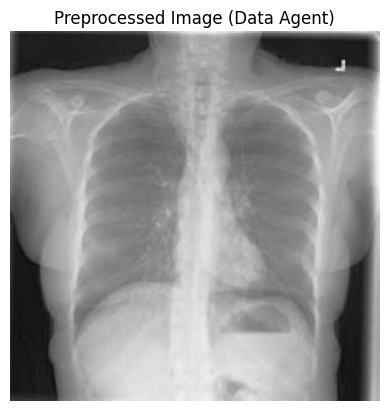

In [5]:
data_agent = DataAgent("/content/drive/MyDrive/lung disease/Lung X-Ray Image/Lung X-Ray Image")
sample_image = data_agent.load_sample()


In [6]:
class VisionAgent:
    def __init__(self):
        self.model = self.build_model()

    def build_model(self):
        model = Sequential([
            Conv2D(16, (3,3), activation='relu', input_shape=(224,224,1)),
            MaxPooling2D(2,2),
            Flatten(),
            Dense(32, activation='relu'),
            Dense(3, activation='softmax')
        ])

        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    def infer(self, image):
        image = image.reshape(1,224,224,1)
        probs = self.model.predict(image)

        print("\n📌 Vision Agent Output (Class Probabilities):")
        for i, cls in enumerate(CLASSES):
            print(f"{cls}: {probs[0][i]:.4f}")

        return probs[0]


In [7]:
vision_agent = VisionAgent()
probs = vision_agent.infer(sample_image)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

📌 Vision Agent Output (Class Probabilities):
Normal: 0.3664
Lung_Opacity: 0.2963
Viral_Pneumonia: 0.3372


In [8]:
class ReasoningAgent:
    def __init__(self, threshold=0.6):
        self.threshold = threshold

    def analyze(self, probs):
        max_prob = np.max(probs)
        pred_class = np.argmax(probs)

        print("\n📌 Reasoning Agent Analysis:")
        print("Predicted Class:", CLASSES[pred_class])
        print("Confidence:", round(max_prob, 3))

        if max_prob < self.threshold:
            print("⚠️ Low Confidence → Ambiguous Case")

        return {
            "class": pred_class,
            "confidence": max_prob,
            "ambiguous": max_prob < self.threshold
        }


In [9]:
reasoning_agent = ReasoningAgent()
reasoning_output = reasoning_agent.analyze(probs)



📌 Reasoning Agent Analysis:
Predicted Class: Normal
Confidence: 0.366
⚠️ Low Confidence → Ambiguous Case


In [10]:
class DecisionAgent:
    def decide(self, reasoning):
        print("\n📌 Decision Agent Output:")

        if reasoning["ambiguous"]:
            print("Decision: NEEDS DOCTOR REVIEW")
        else:
            print("Decision:", CLASSES[reasoning["class"]])

        print("Final Confidence:", round(reasoning["confidence"], 3))


In [11]:
decision_agent = DecisionAgent()
decision_agent.decide(reasoning_output)



📌 Decision Agent Output:
Decision: NEEDS DOCTOR REVIEW
Final Confidence: 0.366


In [12]:
!pip install ipywidgets


In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt


In [14]:
upload = widgets.FileUpload(
    accept='.jpg,.png,.jpeg',
    multiple=False
)

run_button = widgets.Button(
    description="Run Agentic Pipeline",
    button_style='success'
)

output = widgets.Output()


In [15]:
def run_pipeline(b):
    clear_output(wait=True)
    display(upload, run_button, output)

    if len(upload.value) == 0:
        with output:
            print("❌ Please upload an lung X-ray image")
        return

    # Initialize agents
    data_agent = DataAgent()
    vision_agent = VisionAgent()
    reasoning_agent = ReasoningAgent()
    decision_agent = DecisionAgent()

    # Read uploaded image
    uploaded_file = list(upload.value.values())[0]
    img_bytes = uploaded_file['content']

    # ---- DATA AGENT ----
    img = data_agent.preprocess_uploaded_image(img_bytes)

    with output:
        print("📌 DATA AGENT OUTPUT")
        plt.imshow(img, cmap='gray')
        plt.title("Preprocessed X-ray")
        plt.axis('off')
        plt.show()

    # ---- VISION AGENT ----
    probs = vision_agent.infer(img)

    with output:
        print("\n📌 VISION AGENT OUTPUT")
        for i, cls in enumerate(CLASSES):
            print(f"{cls}: {probs[i]:.3f}")

    # ---- REASONING AGENT ----
    reasoning = reasoning_agent.analyze(probs)

    with output:
        print("\n📌 REASONING AGENT OUTPUT")
        print("Predicted Class:", CLASSES[reasoning["class"]])
        print("Confidence:", round(reasoning["confidence"], 3))
        print("Ambiguous:", reasoning["ambiguous"])

    # ---- DECISION AGENT ----
    with output:
        decision_agent.decide(reasoning)

In [16]:
run_button.on_click(run_pipeline)
display(upload, run_button, output)


FileUpload(value={}, accept='.jpg,.png,.jpeg', description='Upload')

Button(button_style='success', description='Run Agentic Pipeline', style=ButtonStyle())

Output()

In [17]:
%%writefile app.py
import streamlit as st
import numpy as np
from PIL import Image
import io

CLASSES = ["Normal Lung", "Pneumonia Lung"]

class DataAgent:
    def preprocess_uploaded_image(self, img_bytes):
        image = Image.open(io.BytesIO(img_bytes)).convert("L")
        image = image.resize((224, 224))
        img = np.array(image) / 255.0
        return img

class VisionAgent:
    def infer(self, img):
        return np.random.dirichlet(np.ones(len(CLASSES)))

class ReasoningAgent:
    def analyze(self, probs):
        return {
            "class": int(np.argmax(probs)),
            "confidence": float(np.max(probs)),
            "ambiguous": float(np.max(probs)) < 0.6
        }

class DecisionAgent:
    def decide(self, reasoning):
        if reasoning["ambiguous"]:
            st.warning("⚠️ Ambiguous prediction. Consult radiologist.")
        else:
            st.success("✅ Confident prediction.")

st.set_page_config(page_title="Lung X-ray Classification System")

st.title("🫁 Lung X-ray Classification using Agentic AI")

uploaded_file = st.file_uploader("Upload lung X-ray", type=["jpg", "png", "jpeg"])

if st.button("Run Diagnosis"):
    if uploaded_file is None:
        st.error("Please upload an image")
    else:
        data_agent = DataAgent()
        vision_agent = VisionAgent()
        reasoning_agent = ReasoningAgent()
        decision_agent = DecisionAgent()

        img = data_agent.preprocess_uploaded_image(uploaded_file.read())
        st.image(img, caption="Preprocessed X-ray", clamp=True)

        probs = vision_agent.infer(img)
        for i, cls in enumerate(CLASSES):
            st.write(f"{cls}: {probs[i]:.3f}")

        reasoning = reasoning_agent.analyze(probs)
        st.write("Prediction:", CLASSES[reasoning["class"]])
        st.write("Confidence:", reasoning["confidence"])

        decision_agent.decide(reasoning)


Overwriting app.py


In [18]:
!pip install streamlit pyngrok


In [19]:
!ngrok config add-authtoken 3AVl7nSP2wnhqwPnl0KCIYV5WDJ_4xJAYkCwJFKL74aUaR2RX


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [20]:
from pyngrok import ngrok
ngrok.kill()
public_url = ngrok.connect(8501)
print("OPEN THIS URL:", public_url)

OPEN THIS URL: NgrokTunnel: "https://sloshiest-cravenly-starr.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!streamlit run app.py &





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.66.243.7:8501

